<a href="https://colab.research.google.com/github/SujalGodse/Advance-Analytics-using-Statistics/blob/main/Advance_Analytics_using_statistics_Day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t

In [6]:
# pribability is 70%
binom.pmf(50,80,0.7)
binom.cdf(49,80,0.7)

np.float64(0.058748113591172955)

In [7]:
# an incident occurs happen on an average
poisson.pmf(5,7)
poisson.cdf(5,7)

np.float64(0.3007082761743609)

In [8]:
# normal curve
norm.cdf(43,45,2.8)

# std Normalcurve
# z =  (prob - mean)/ std
z = (43-45)/2.8
# norm(z,0,1)
norm(z)

In [9]:
norm.cdf(1.73)

np.float64(0.9581848623864051)

In [10]:
# Students t distribution
# Q. 15 trips, mean = 15.3, std = 1.8 , <=14
z = (14-15.3)/1.8
print(z)
t.cdf(z,14)

-0.7222222222222227


np.float64(0.2410240907076217)

In [11]:
# how many on an average hour 200 incidnts are taking placce in a year
(365*24)/200 # hour/incident - avg hour per incident
200/(365*24) # incident/hour - rate of failure

0.0228310502283105

In [12]:
from scipy.stats import expon
expon.cdf(100,scale=43.8)

np.float64(0.898032895521957)

In [13]:
# you are living near station, per day 80 horns are heard. how many avg horns are heard per hour and if i have to know
print(24/80) # scale = MTBF Mean  Time Between Failures
print(expon.cdf(1,scale=0.3))
print(1-expon.cdf(1,scale=0.3))

0.3
0.9643260066527476
0.03567399334725241


In [14]:
# on an avg sir comes 30 times in a 45 days of course. 1 day = 8 hours. what is probabability that they will come today
print((45*8)/30)
expon.cdf(8,scale=12)   # 1-day = 8 hours

12.0


np.float64(0.486582880967408)

In [15]:
df = pd.read_excel("/content/drive/MyDrive/CDAC/data1.xlsx")
df.head()

,Category
0,C
1,D
2,C
3,A
4,B


In [16]:
# find missing value
df.Category.isnull().sum()

np.int64(80)

In [17]:
np.where(df.Category.isnull())

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [18]:
80/df.shape[0]

0.16

In [19]:
from  collections import Counter
Counter(df.Category).most_common()

[('B', 113), ('A', 112), ('C', 101), ('D', 94), (nan, 80)]

In [20]:
# option 1
df.Category.fillna('B',inplace=True)  # mode = 8 -> df.Category.mode()


/tmp/ipykernel_1135/211479443.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Category.fillna('B',inplace=True)  # mode = 8 -> df.Category.mode()


In [21]:
df.isnull().sum()

,0
Category,0


In [22]:
# option 2
df.Category = df.Category.fillna('B')

In [23]:
df.Category.isnull().sum()

np.int64(0)

Filling NaN values with proportion

In [24]:
df = pd.read_excel("/content/drive/MyDrive/CDAC/data1.xlsx")
df.head()

,Category
0,C
1,D
2,C
3,A
4,B


In [25]:
df.Category.isnull().sum()

np.int64(80)

In [26]:
df.Category.value_counts()

,count
Category,
B,113
A,112
C,101
D,94


In [27]:
props = pd.DataFrame(df.Category.value_counts())

In [28]:
props["proportion"] = props['count']/sum(props['count'])
props

,count,proportion
Category,,
B,113,0.269048
A,112,0.266667
C,101,0.240476
D,94,0.223810


In [29]:
random_values = np.random.choice(['A','B','C','D'],size=80,p=props.proportion)

In [30]:
ind = np.where(df.Category.isnull())
ind

(array([  9,  11,  15,  32,  35,  38,  47,  48,  58,  59,  62,  64,  80,
         81,  82,  84,  95,  98, 122, 123, 140, 156, 161, 163, 164, 165,
        166, 167, 170, 174, 176, 177, 188, 192, 193, 212, 217, 223, 227,
        231, 237, 238, 246, 248, 250, 254, 257, 260, 267, 268, 269, 278,
        281, 287, 303, 328, 329, 333, 342, 345, 349, 357, 382, 384, 387,
        404, 406, 441, 445, 447, 451, 456, 459, 464, 471, 476, 477, 490,
        492, 494]),)

In [31]:
df.loc[ind[0],'Category'] = random_values
df.Category.isnull().sum()              # null values replcaed with random_values

np.int64(0)

# **Problem 2**

In [32]:
df1 = pd.read_excel("/content/drive/MyDrive/CDAC/data2.xlsx")
df1.head()

,Category,Continuous_Value
0,C,-4008.098297
1,D,-3887.888132
2,NaN,-3712.188312
3,C,-3416.823821
4,D,-5845.073897


In [33]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          850 non-null    object 
 1   Continuous_Value  880 non-null    float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


In [34]:
df1.Continuous_Value = df1.Continuous_Value.fillna(df1.Continuous_Value.median())

In [35]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Category          850 non-null    object 
 1   Continuous_Value  1000 non-null   float64
dtypes: float64(1), object(1)
memory usage: 15.8+ KB


In [36]:
df1.Continuous_Value

,Continuous_Value
0,-4008.098297
1,-3887.888132
2,-3712.188312
3,-3416.823821
4,-5845.073897
...,...
995,4254.526508
996,4056.149295
997,5030.236615
998,4734.230414


# **Outliers**

In [37]:
# Steps : Q1,Q2,Q3,IQR,UF,LF,highest between Q3 and UF, lowest between Q1 and LF, any values greater then UF is outlier, any values less then LF is outlier.


# **Data Visualization**

1. check data type
2. find missing values and handle it
3. perform data preproceesing and make it clean and ready to use


In [38]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

### **Bar Chart**

<BarContainer object of 5 artists>

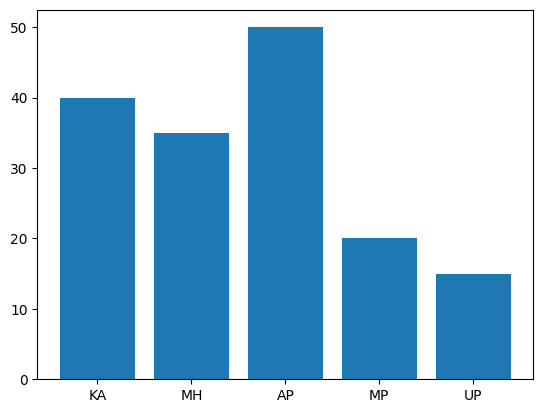

In [39]:
states = ['KA','MH','AP','MP','UP']
counts = [40,35,50,20,15]

plt.bar(states,counts)

Text(0.5, 0, 'N')

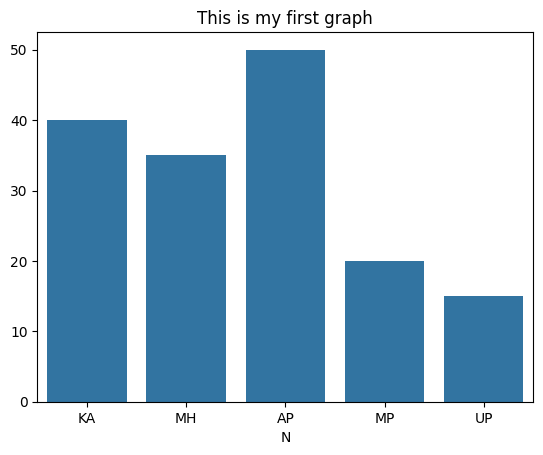

In [40]:
# seaborn
sns.barplot(x=states,y=counts)
plt.title("This is my first graph")
plt.xlabel("N")

In [41]:
df = pd.read_excel("/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx",sheet_name='ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


MaterialID
TMI-43T    15
AXCP-78    11
DDBN-89     8
SDRT-67     6
GCVB-79     5
LXCV-21     5
Name: count, dtype: int64


<BarContainer object of 6 artists>

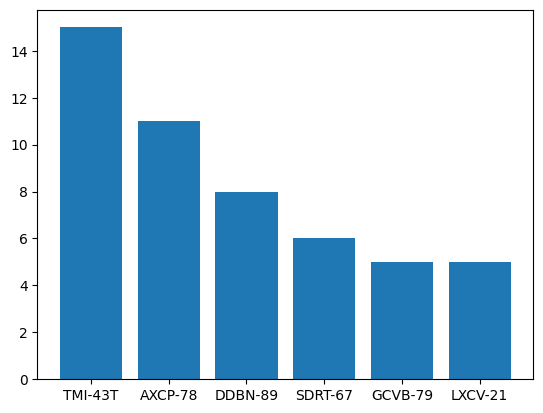

In [42]:
# bar plot for frequency
df1 = df.MaterialID.value_counts()
print(df1)

plt.bar(df1.index,df1)

{'AXCP-78': [1, 3, 4, 24, 25, 37, 38, 39, 46, 47, 48], 'DDBN-89': [22, 23, 26, 30, 40, 43, 45, 49], 'GCVB-79': [8, 15, 34, 35, 36], 'LXCV-21': [2, 27, 28, 29, 44], 'SDRT-67': [10, 11, 16, 17, 41, 42], 'TMI-43T': [0, 5, 6, 7, 9, 12, 13, 14, 18, 19, 20, 21, 31, 32, 33]}
MaterialID
AXCP-78    898
DDBN-89    383
GCVB-79    182
LXCV-21    243
SDRT-67    294
TMI-43T    885
Name: Quantity, dtype: int64


<BarContainer object of 6 artists>

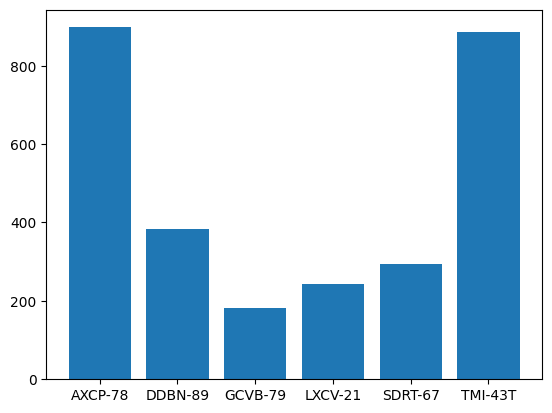

In [43]:
# bar plot for total
grp1 = df.groupby('MaterialID')
print(grp1.groups)
df_2 = grp1.Quantity.agg('sum')
print(df_2)
plt.bar(df_2.index,df_2)

MaterialID  AXCP-78  DDBN-89  GCVB-79  LXCV-21  SDRT-67  TMI-43T
Location                                                        
MWH-1             5        3        0        0        2        1
MWH-2             1        1        4        1        1        1
MWH-3             1        1        0        1        0        1
MWH-4             1        2        0        0        1       11
MWH-5             3        1        1        3        2        1


<Axes: xlabel='Location'>

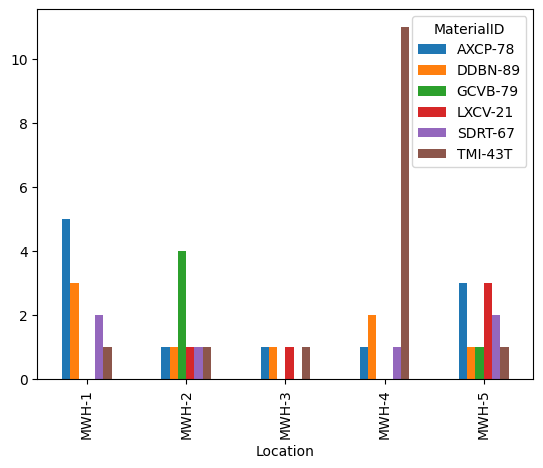

In [44]:
df.head()
df1 = pd.crosstab(df.Location,df.MaterialID)
print(df1)

df1.plot(kind='bar')

Example on nominal data of databook exel
### Effect of categorical data on another categprical data
then we have to use group bar chart

In [45]:
df = pd.read_excel("/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx",sheet_name='nominal')
df.head()

,ses,write,math,prog
0,1,35,41,1
1,2,33,41,2
2,3,39,44,3
3,1,37,42,1
4,2,31,40,2


prog   1   2   3
ses             
1     29  16   2
2      6  51  38
3      1   9  48


<Axes: xlabel='ses'>

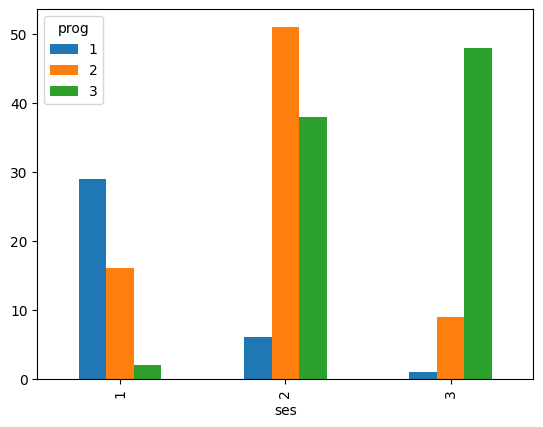

In [46]:
# ses have any effect on programs(prog) or not

df1 = pd.crosstab(df.ses,df.prog)
print(df1)

df1.plot(kind='bar')


### **Effect of categorical data on continuous data**
Then we have to use bar plot

{'whiskers': [<matplotlib.lines.Line2D at 0x7a64a97e92b0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a64a97e8c50>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a64a96b1a60>],
 'medians': [<matplotlib.lines.Line2D at 0x7a64a96251c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a64a9681be0>],
 'means': []}

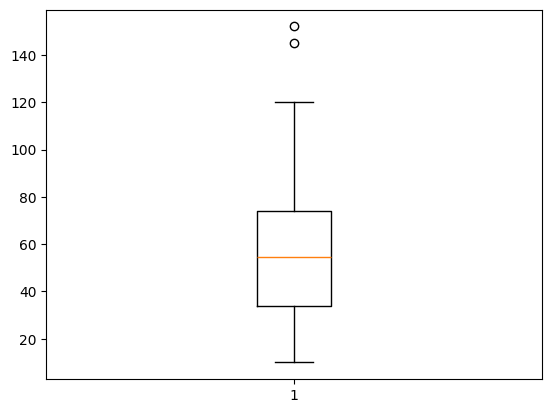

In [47]:
df = pd.read_excel("/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx",sheet_name='ERPData')
plt.boxplot(df.Quantity)

{'whiskers': [<matplotlib.lines.Line2D at 0x7a64a9401ca0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a64a9402210>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a64a9401a00>,
 'medians': [<matplotlib.lines.Line2D at 0x7a64a94027b0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7a64a94029f0>,
 'means': []}

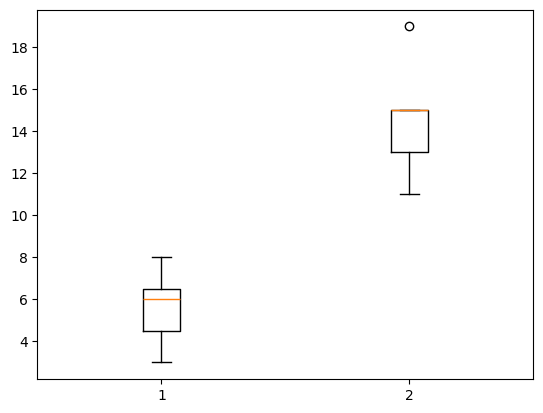

In [48]:
male_sal = [4,6,5,3,7,6,8]
female_sal = [11,15,13,19,15]
plt.boxplot([male_sal,female_sal])